In [118]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# 한글 폰트 설정
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

In [119]:
# ============================================================
# 프로젝트 경로 설정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정
# ============================================================

ROOT = Path(r"C:\Users\joon5\Documents\github\Anti-Churn-Committee")

DATA_RAW_DIR = ROOT / "data" / "raw"
DATA_PROCESSED_DIR = ROOT / "data" / "processed"

USER_PROFILE_FILE = "01_User_Profile.csv"
EVENT_LOG_FILE = "02_Event_Log.csv"

USER_PROFILE_PATH = DATA_RAW_DIR / USER_PROFILE_FILE
EVENT_LOG_PATH = DATA_RAW_DIR / EVENT_LOG_FILE

print("USER_PROFILE_PATH:", USER_PROFILE_PATH)
print("EVENT_LOG_PATH   :", EVENT_LOG_PATH)

USER_PROFILE_PATH: C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\raw\01_User_Profile.csv
EVENT_LOG_PATH   : C:\Users\joon5\Documents\github\Anti-Churn-Committee\data\raw\02_Event_Log.csv


In [120]:
df_raw01 = pd.read_csv(USER_PROFILE_PATH)
df_raw02 = pd.read_csv(EVENT_LOG_PATH)

print("df_raw01 shape:", df_raw01.shape)
print("df_raw02 shape:", df_raw02.shape)

display(df_raw01.head())
display(df_raw02.head())

df_raw01 shape: (12500, 6)
df_raw02 shape: (1757262, 5)


,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자
0,U0000001,2025-01-25,오가닉,iOS,True,NaN
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24
2,U0000003,2025-05-14,오가닉,iOS,False,NaN
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaN
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaN


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성


In [121]:
# ============================================================
# 1. 기초 전처리용 데이터 복사
# ============================================================
user_profile_base = df_raw01.copy()
event_log_base = df_raw02.copy()

In [122]:
# ============================================================
# 2. 공백 제거
# - 컬럼명과 문자열 값의 앞뒤 공백 제거
# - 문자열이 아닌 값은 그대로 유지
# ============================================================

# 컬럼명 앞뒤 공백 제거
user_profile_base.columns = [
    col.strip() if isinstance(col, str) else col
    for col in user_profile_base.columns
]

event_log_base.columns = [
    col.strip() if isinstance(col, str) else col
    for col in event_log_base.columns
]

In [123]:
# ============================================================
# 3. User_ID 타입 통일
# - 두 데이터를 User_ID로 연결하기 위해 문자열 타입으로 통일
# ============================================================
user_profile_base["User_ID"] = user_profile_base["User_ID"].astype(str)
event_log_base["User_ID"] = event_log_base["User_ID"].astype(str)

In [124]:
# ============================================================
# 4. 날짜 컬럼 datetime 변환
# - 변환 실패값은 NaT로 남김
# - 아직 행 제거는 하지 않음
# ============================================================
user_profile_base["가입일자"] = pd.to_datetime(
    user_profile_base["가입일자"],
    errors="coerce"
)

user_profile_base["알림수신동의_변경일자"] = pd.to_datetime(
    user_profile_base["알림수신동의_변경일자"],
    errors="coerce"
)

event_log_base["Event_Time"] = pd.to_datetime(
    event_log_base["Event_Time"],
    errors="coerce"
)

In [125]:
# ============================================================
# 5. 날짜 파생 컬럼 생성
# - 코호트, 리텐션, 일별/월별 분석에 사용할 기본 컬럼 생성
# - 아직 Day 0, Day 30 기준은 확정하지 않음
# ============================================================

user_profile_base["가입일"] = user_profile_base["가입일자"].dt.normalize()
user_profile_base["가입월"] = user_profile_base["가입일자"].dt.to_period("M").astype(str)

event_log_base["Event_Date"] = event_log_base["Event_Time"].dt.normalize()
event_log_base["Event_Month"] = event_log_base["Event_Time"].dt.to_period("M").astype(str)
event_log_base["Event_Hour"] = event_log_base["Event_Time"].dt.hour

In [126]:
# ============================================================
# 6. EDA용 데이터 복사 및 기준값 설정
# - 기초 전처리 데이터는 유지하고, EDA용 데이터프레임을 따로 생성
# ============================================================

user_profile_eda = user_profile_base.copy()
event_log_eda = event_log_base.copy()

# 주요 이벤트 그룹 정의
notification_events = ["알림수신", "알림오픈"]

in_app_events = [
    "앱실행",
    "수면기록",
    "운동기록",
    "마음챙김",
    "식단기록",
    "챌린지_탐색",
    "챌린지참여",
    "온보딩_완료"
]

challenge_events = ["챌린지_탐색", "챌린지참여"]

# 로그 수집 장애 기간
issue_start_date = pd.Timestamp("2025-03-10")
issue_end_date = pd.Timestamp("2025-03-14")

# 데이터 기간
data_start_time = event_log_eda["Event_Time"].min()
data_end_time = event_log_eda["Event_Time"].max()
data_end_date = data_end_time.normalize()

print("user_profile_eda shape:", user_profile_eda.shape)
print("event_log_eda shape   :", event_log_eda.shape)
print("이벤트 시작 시점:", data_start_time)
print("이벤트 종료 시점:", data_end_time)
print("분석 기준 종료일:", data_end_date)


user_profile_eda shape: (12500, 8)
event_log_eda shape   : (1757262, 8)
이벤트 시작 시점: 2025-01-01 07:00:07
이벤트 종료 시점: 2025-06-30 22:59:51
분석 기준 종료일: 2025-06-30 00:00:00


In [127]:
# ============================================================
# 7. 이벤트 구분 플래그 생성
# - 알림 이벤트, 앱 내부 이벤트, 챌린지 이벤트, 장애 기간 여부 구분
# ============================================================

event_log_eda["is_notification_event"] = event_log_eda["Event_Type"].isin(notification_events)
event_log_eda["is_in_app_event"] = event_log_eda["Event_Type"].isin(in_app_events)
event_log_eda["is_challenge_event"] = event_log_eda["Event_Type"].isin(challenge_events)

event_log_eda["is_issue_period"] = (
    (event_log_eda["Event_Date"] >= issue_start_date) &
    (event_log_eda["Event_Date"] <= issue_end_date)
)

display(event_log_eda.head())


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형,Event_Date,Event_Month,Event_Hour,is_notification_event,is_in_app_event,is_challenge_event,is_issue_period
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,7,False,True,False,False
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,7,False,True,False,False
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,7,False,True,True,False
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,7,False,True,True,False
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,20,True,False,False,False


In [128]:
# ============================================================
# 8. 기본 전처리 결과 확인
# ============================================================

print("user_profile 원본 shape :", df_raw01.shape)
print("user_profile_base shape :", user_profile_base.shape)

print("event_log 원본 shape    :", df_raw02.shape)
print("event_log_base shape    :", event_log_base.shape)

display(user_profile_base.head())
display(event_log_base.head())

user_profile 원본 shape : (12500, 6)
user_profile_base shape : (12500, 8)
event_log 원본 shape    : (1757262, 5)
event_log_base shape    : (1757262, 8)


,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자,가입일,가입월
0,U0000001,2025-01-25,오가닉,iOS,True,NaT,2025-01-25,2025-01
1,U0000002,2025-05-06,오가닉,iOS,False,2025-05-24,2025-05-06,2025-05
2,U0000003,2025-05-14,오가닉,iOS,False,NaT,2025-05-14,2025-05
3,U0000004,2025-02-23,퍼포먼스광고,Android,True,NaT,2025-02-23,2025-02
4,U0000005,2025-02-18,퍼포먼스광고,Android,True,NaT,2025-02-18,2025-02


,User_ID,Event_Time,Event_Type,Session_ID,알림_유형,Event_Date,Event_Month,Event_Hour
0,U0000001,2025-01-25 07:25:45,앱실행,2858201769,NaN,2025-01-25,2025-01,7
1,U0000001,2025-01-25 07:26:15,온보딩_완료,2858201769,NaN,2025-01-25,2025-01,7
2,U0000001,2025-01-25 07:26:55,챌린지_탐색,2858201769,NaN,2025-01-25,2025-01,7
3,U0000001,2025-01-25 07:27:55,챌린지참여,2858201769,NaN,2025-01-25,2025-01,7
4,U0000001,2025-01-25 20:30:00,알림수신,NaN,광고성,2025-01-25,2025-01,20


# 전터리 전 파악해야할 내용

1. 분석 기간과 가입/이벤트 데이터 범위
2. 월별 가입자 수와 이벤트 수 흐름
3. 로그 수집 장애 기간의 영향
4. `Event_Type` 결측치의 분포와 처리 기준
5. `Session_ID` 결측이 알림 이벤트와 관련 있는지 여부
6. `알림_유형` 결측이 정상 구조인지 여부
7. 리텐션 계산에 사용할 활성 이벤트 기준
8. D7/D30 리텐션 관측 가능 사용자 범위
9. 사용자별 활동량 분포와 고활동 사용자 여부
10. 온보딩, 챌린지 경험 여부와 이후 분석 기준

# 내용 파악 시작

## 1. 분석 기간과 데이터 규모 확인

가입자 데이터와 이벤트 로그의 기간, 사용자 수, 기본 규모를 먼저 확인

In [129]:
# ============================================================
# 1. 분석 기간 및 데이터 범위 확인
# ============================================================

print("[User_Profile 가입일자 범위]")
print("가입일자 최소:", user_profile_eda["가입일자"].min())
print("가입일자 최대:", user_profile_eda["가입일자"].max())

print("\n[Event_Log 이벤트 시간 범위]")
print("Event_Time 최소:", event_log_eda["Event_Time"].min())
print("Event_Time 최대:", event_log_eda["Event_Time"].max())

print("\n[기본 사용자 수]")
print("가입자 수:", user_profile_eda["User_ID"].nunique())
print("이벤트 로그 사용자 수:", event_log_eda["User_ID"].nunique())

print("\n[기본 이벤트 수]")
print("전체 이벤트 수:", len(event_log_eda))
print("앱 내부 이벤트 수:", event_log_eda["is_in_app_event"].sum())
print("알림 이벤트 수:", event_log_eda["is_notification_event"].sum())


[User_Profile 가입일자 범위]
가입일자 최소: 2025-01-01 00:00:00
가입일자 최대: 2025-05-26 00:00:00

[Event_Log 이벤트 시간 범위]
Event_Time 최소: 2025-01-01 07:00:07
Event_Time 최대: 2025-06-30 22:59:51

[기본 사용자 수]
가입자 수: 12500
이벤트 로그 사용자 수: 12453

[기본 이벤트 수]
전체 이벤트 수: 1757262
앱 내부 이벤트 수: 1515263
알림 이벤트 수: 215543


### 결과 해석
- 가입자 데이터는 **2025-01-01부터 2025-05-26까지** 존재하고, 이벤트 로그는 **2025-01-01부터 2025-06-30까지** 존재한다.   
가입자는 총 **12,500명**이고, 이벤트 로그에 실제로 등장한 사용자는 **12,453명**이다.

- 전체 이벤트는 **1,757,262건**이며, 이 중 앱 내부 이벤트는 **1,515,263건**, 알림 이벤트는 **215,543건**으로 확인된다. 

즉, 이 데이터는 사용자 프로필보다 이벤트 로그가 훨씬 큰 구조이며, 이후 분석은 사용자 단위와 이벤트 단위를 구분해서 진행해야 한다.

전처리 기준으로는 이벤트 로그에 없는 **47명**을 바로 삭제하기보다, 가입자는 했지만 로그가 없는 사용자로 따로 확인하는 것이 좋다.

## 2. 월별 가입자 수와 이벤트 수 흐름 확인

가입자 수는 늘고 있는지, 이벤트 수와 활동 사용자 수는 어떤 흐름을 보이는지 확인한다.

,가입월,signup_user_count
0,2025-01,2124
1,2025-02,4384
2,2025-03,2122
3,2025-04,2082
4,2025-05,1788


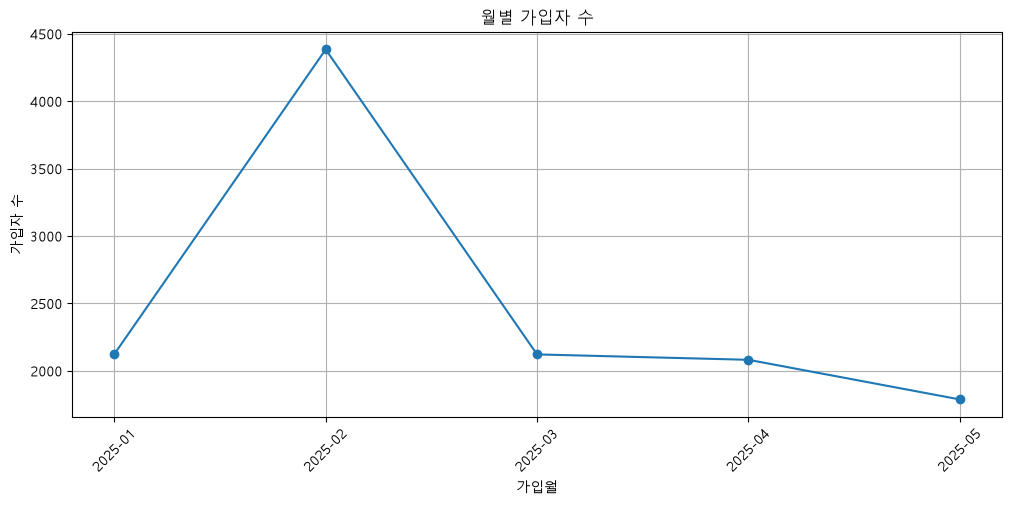

,Event_Month,event_count,active_user_count,session_count
0,2025-01,117105,2124,46414
1,2025-02,337154,5272,137237
2,2025-03,386739,4984,163646
3,2025-04,420330,5296,177166
4,2025-05,349351,5001,148445
5,2025-06,146583,1681,63373


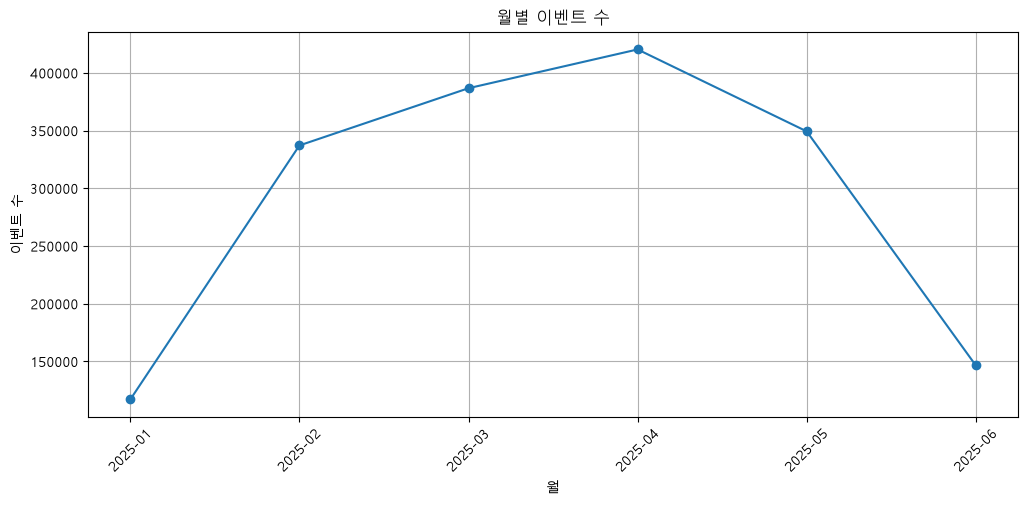

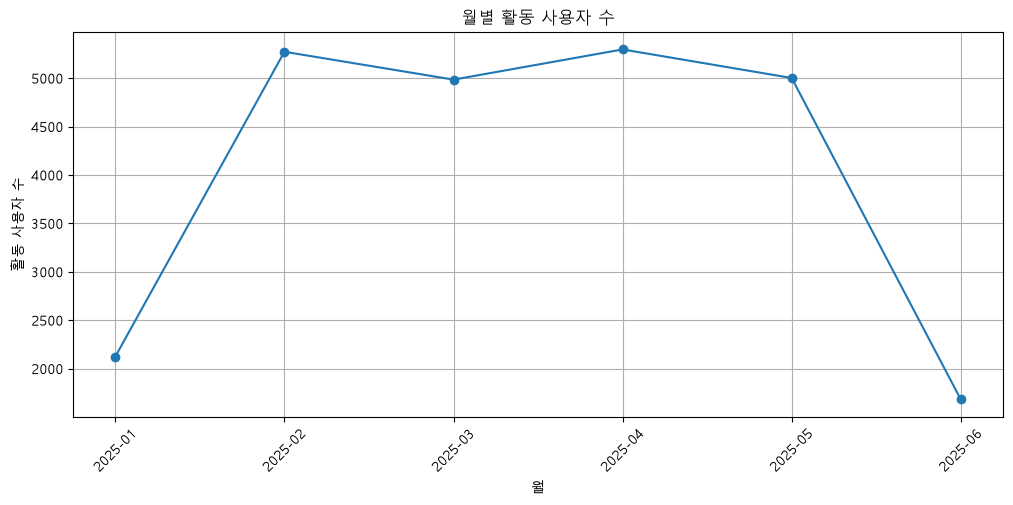

In [131]:
# ============================================================
# 2-1. 월별 가입자 수 확인
# ============================================================

monthly_signup = (
    user_profile_eda
    .groupby("가입월")
    .agg(signup_user_count=("User_ID", "nunique"))
    .reset_index()
)

display(monthly_signup)

plt.figure(figsize=(12, 5))
plt.plot(monthly_signup["가입월"], monthly_signup["signup_user_count"], marker="o")
plt.title("월별 가입자 수")
plt.xlabel("가입월")
plt.ylabel("가입자 수")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ============================================================
# 2-2. 월별 이벤트 수 및 활동 사용자 수 확인
# ============================================================

monthly_event = (
    event_log_eda
    .groupby("Event_Month")
    .agg(
        event_count=("User_ID", "size"),
        active_user_count=("User_ID", "nunique"),
        session_count=("Session_ID", "nunique")
    )
    .reset_index()
)

display(monthly_event)

plt.figure(figsize=(12, 5))
plt.plot(monthly_event["Event_Month"], monthly_event["event_count"], marker="o")
plt.title("월별 이벤트 수")
plt.xlabel("월")
plt.ylabel("이벤트 수")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_event["Event_Month"], monthly_event["active_user_count"], marker="o")
plt.title("월별 활동 사용자 수")
plt.xlabel("월")
plt.ylabel("활동 사용자 수")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 결과 해석

월별 가입자 수는 **2025년 2월 4,384명**으로 가장 많고, 이후 3월 **2,122명**, 4월 **2,082명**, 5월 **1,788명**으로 줄어든다. 

5월은 가입일자가 5월 26일까지 존재하므로, 단순히 가입 감소라고만 보기보다는 데이터 기간이 일부 짧다는 점을 같이 고려해야 한다.

월별 이벤트 수는 1월 **117,105건**에서 4월 **420,330건**까지 증가한 뒤, 5월 **349,351건**, 6월 **146,583건**으로 감소한다. 

활동 사용자 수 또한 4월 **5,296명** 이후 6월 **1,681명**으로 크게 줄어든다.

이 결과만 보면 서비스 사용량이 4월 이후 감소한 것으로 보인다. 다만 6월에는 신규 가입 데이터가 없고, 기존 가입자의 시간이 지난 후 행동만 관측되는 구조이므로, 단순 사용량 감소와 리텐션 하락을 구분해서 봐야 한다.   
이후 분석을 통해선 월별 집계뿐 아니라 가입월 기준 코호트 분석이 필요로하다.

## 3. 로그 수집 장애 기간 확인

안내상 **2025-03-10 ~ 2025-03-14**는 로그 수집 장애 기간으로    
해당 기간의 이벤트 수가 전후 흐름과 다르게 나타나는지 확인한다.


[집계 결과 일부 확인]


,Event_Date,event_count,active_user_count,session_count
0,2025-01-01,665,65,239
1,2025-01-02,1239,140,473
2,2025-01-03,1665,197,635
3,2025-01-04,1950,252,751
4,2025-01-05,2288,297,897


[로그 수집 장애 기간 일별 이벤트 수]


,Event_Date,event_count,active_user_count,session_count
68,2025-03-10,4157,786,1860
69,2025-03-11,4389,773,1900
70,2025-03-12,4261,760,1794
71,2025-03-13,4268,803,1814
72,2025-03-14,3787,715,1624


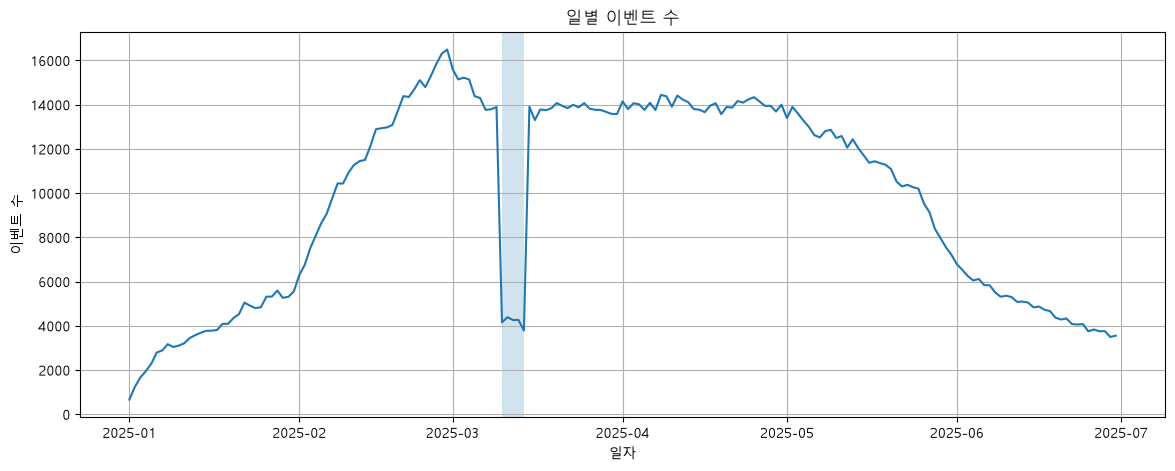

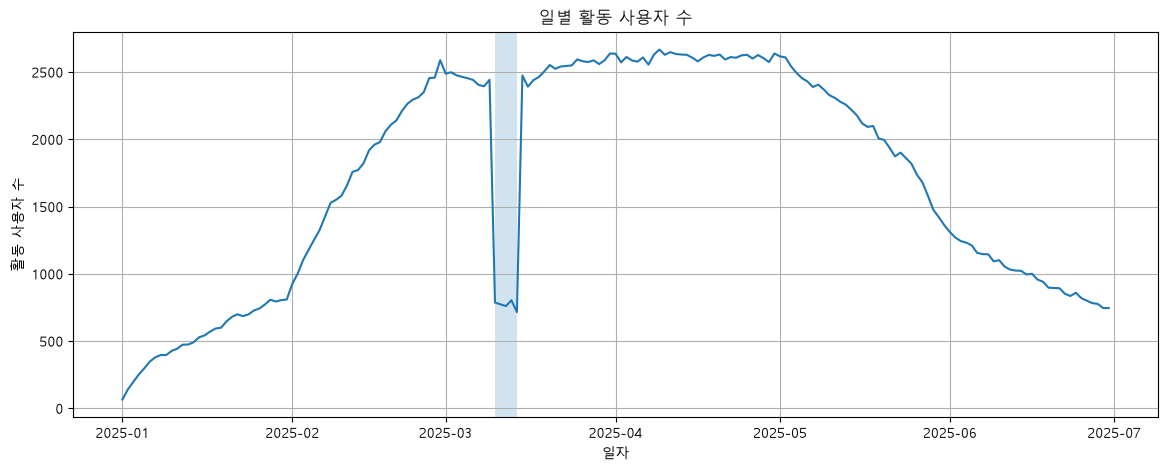

In [ ]:
# ============================================================
# 3. 일별 이벤트 수와 로그 수집 장애 기간 확인
# ============================================================

# 날짜별 이벤트 수, 활동 사용자 수, 세션 수 집계
daily_event = (
    event_log_eda
    .groupby("Event_Date")
    .agg(
        event_count=("User_ID", "size"),           # 날짜별 전체 이벤트 수
        active_user_count=("User_ID", "nunique"),  # 날짜별 이벤트를 남긴 사용자 수
        session_count=("Session_ID", "nunique")    # 날짜별 세션 수
    )
    .reset_index()
)

# 로그 수집 장애 기간만 따로 확인
issue_daily_event = daily_event[
    (daily_event["Event_Date"] >= issue_start_date) &
    (daily_event["Event_Date"] <= issue_end_date)
]

# 집계 결과 일부 확인
print("[집계 결과 일부 확인]")
display(daily_event.head())

# 일별 이벤트 수 그래프
print("[로그 수집 장애 기간 일별 이벤트 수]")
display(issue_daily_event)

plt.figure(figsize=(14, 5))
plt.plot(daily_event["Event_Date"], daily_event["event_count"])
plt.axvspan(issue_start_date, issue_end_date, alpha=0.2)
plt.title("일별 이벤트 수")
plt.xlabel("일자")
plt.ylabel("이벤트 수")
plt.grid(True)
plt.show()

### 결과 해석

일별 이벤트 수를 확인한 결과, 로그 수집 장애 기간인 **2025-03-10부터 2025-03-14까지** 이벤트 수가 뚜렷하게 감소했다.        
해당 기간 일별 이벤트 수는 약 **3,787건~4,389건** 수준인데, 장애 직전 7일 평균은 약 **14,359건**, 장애 직후 7일 평균은 약 **13,803건** 수준이었다.

따라서 이 구간은 실제 사용자 행동 감소라기보다 로그 수집 장애의 영향으로 보는 것이 적절하다.    
이 기간을 아무 표시 없이 리텐션이나 일별 활성 지표에 사용하면 실제보다 활동이 낮게 계산될 수 있다.

전처리 단계에서 이 기간을 바로 제거하기보다는, 우선 플래그를 유지하고 분석 결과에 어떤 영향을 주는지 비교하는 방식이 좋다. 특히 D7, D30 계산 구간에 이 기간이 포함되는 사용자는 별도로 주의해야 한다.

## 4. Event_Type 분포와 결측 패턴 확인

,Event_Type,event_count,비율(%)
0,앱실행,728657,41.47
1,수면기록,242978,13.83
2,알림수신,194324,11.06
3,운동기록,131269,7.47
4,마음챙김,130344,7.42
5,식단기록,101366,5.77
6,챌린지참여,96829,5.51
7,챌린지_탐색,78101,4.44
8,결측,26456,1.51
9,알림오픈,21219,1.21


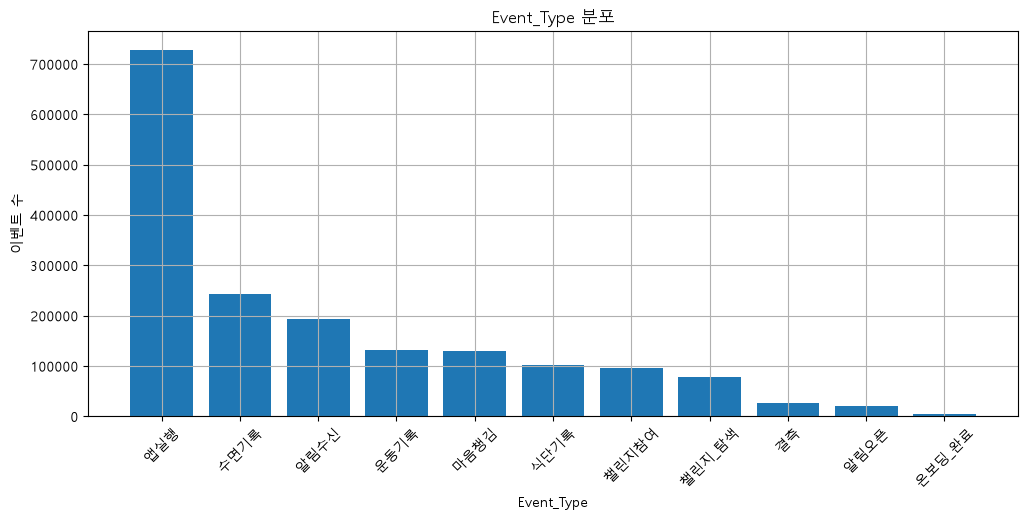

Event_Type 결측 행 수: 26456
Event_Type 결측 사용자 수: 7206
Event_Type 결측 세션 수: 22520


,Event_Date,missing_event_count
0,2025-01-01,9
1,2025-01-02,14
2,2025-01-03,30
3,2025-01-04,29
4,2025-01-05,33


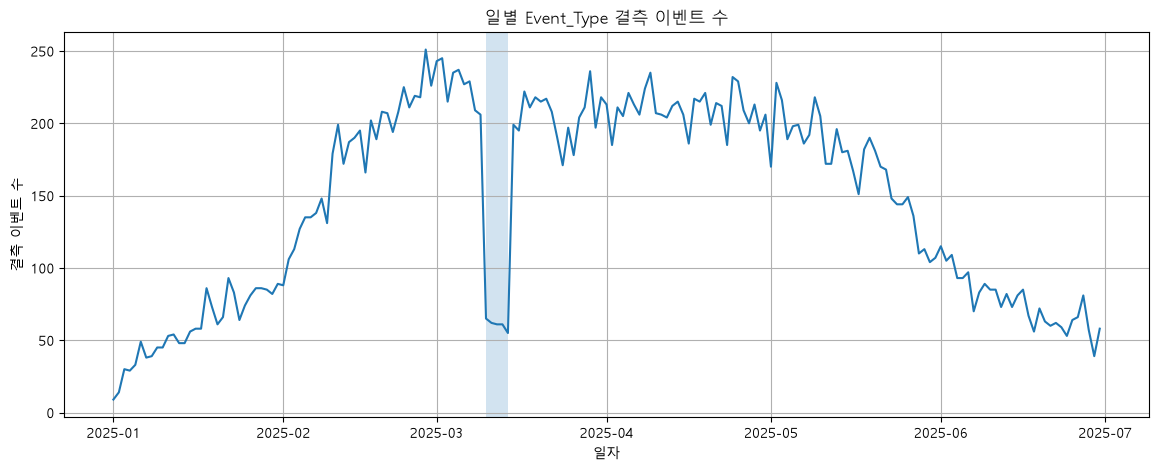

장애 기간 내 Event_Type 결측 수: 304
장애 기간 내 Event_Type 결측 비율(%): 1.15


In [133]:
# ============================================================
# 4-1. Event_Type 분포 확인
# ============================================================
# Event_Type별 이벤트 수 집계
event_type_summary = (
    event_log_eda["Event_Type"]
    .fillna("결측")
    .value_counts(dropna=False)
    .reset_index()
)

# 전체 이벤트 수 대비 비율 계산
event_type_summary.columns = ["Event_Type", "event_count"]
event_type_summary["비율(%)"] = (
    event_type_summary["event_count"] / len(event_log_eda) * 100
).round(2)

display(event_type_summary)

# Event_Type 분포 막대 그래프
plt.figure(figsize=(12, 5))
plt.bar(
    event_type_summary["Event_Type"].astype(str),
    event_type_summary["event_count"]
)
plt.title("Event_Type 분포")
plt.xlabel("Event_Type")
plt.ylabel("이벤트 수")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# ============================================================
# 4-2. Event_Type 결측 패턴 확인
# ============================================================
# Event_Type이 결측인 행만 따로 추출
event_type_missing = event_log_eda[event_log_eda["Event_Type"].isnull()].copy()

print("Event_Type 결측 행 수:", len(event_type_missing))
print("Event_Type 결측 사용자 수:", event_type_missing["User_ID"].nunique())
print("Event_Type 결측 세션 수:", event_type_missing["Session_ID"].nunique())

# 날짜별 Event_Type 결측 이벤트 수 집계
missing_by_date = (
    event_type_missing
    .groupby("Event_Date")
    .size()
    .reset_index(name="missing_event_count")
)

# 날짜 타입 정리
missing_by_date["Event_Date"] = pd.to_datetime(
    missing_by_date["Event_Date"],
    errors="coerce"
)

display(missing_by_date.head())

# 결측 이벤트가 날짜별로 어떻게 발생하는지 선 그래프로 확인
if len(missing_by_date) > 0:
    # 결측 이벤트 수도 날짜 흐름을 보려고 선 그래프 사용
    plt.figure(figsize=(14, 5))
    plt.plot(
        missing_by_date["Event_Date"],
        missing_by_date["missing_event_count"]
    )
    # 장애 기간을 음영으로 표시해서 결측 발생 시점과 비교
    plt.axvspan(issue_start_date, issue_end_date, alpha=0.2)
    plt.title("일별 Event_Type 결측 이벤트 수")
    plt.xlabel("일자")
    plt.ylabel("결측 이벤트 수")
    plt.grid(True)
    plt.show()

# Event_Type 결측 중 장애 기간에 포함된 로그 수 확인
missing_issue_count = event_type_missing["is_issue_period"].sum()
print("장애 기간 내 Event_Type 결측 수:", missing_issue_count)

# 결측 로그가 0건일 수도 있으므로 0으로 나누는 오류 방지
if len(event_type_missing) > 0:
    print(
        "장애 기간 내 Event_Type 결측 비율(%):",
        round(missing_issue_count / len(event_type_missing) * 100, 2)
    )

### 결과 해석

`Event_Type` 분포에서는 `앱실행`이 **728,657건, 41.47%**로 가장 많다.   
그 다음으로 `수면기록` **13.83%**, `알림수신` **11.06%**, `운동기록` **7.47%**, `마음챙김` **7.42%** 순으로 나타난다. 

**즉, 사용자의 기본 활동은 앱 실행과 루틴 기록 중심으로 구성되어 있다.**

`Event_Type` 결측은 **26,456건, 1.51%**이고, 결측 로그는 **7,206명**, **22,520개 세션**에 걸쳐 나타났다.     
장애 기간 안에 포함된 결측은 **304건, 1.15%**로 낮기 때문에, `Event_Type` 결측이 로그 수집 장애 기간에만 집중된 문제라고 보기는 어렵다.

따라서 행동 종류가 필요한 분석에서는 `Event_Type` 결측 로그를 제외하거나 `Unknown`으로 따로 분리해야 한다.

## 5. Session_ID 결측 구조 확인

`Session_ID` 결측이 알림 이벤트에서 주로 발생하는지 확인. 알림 이벤트는 앱 외부에서 발생할 수 있으므로 일반 세션과 다르게 볼 필요가 있다.


,Event_Type,is_session_missing,event_count
0,마음챙김,False,128430
1,마음챙김,True,1914
2,수면기록,False,239437
3,수면기록,True,3541
4,식단기록,False,99833
5,식단기록,True,1533
6,알림수신,True,194324
7,알림오픈,True,21219
8,앱실행,False,718047
9,앱실행,True,10610


,is_notification_event,event_count,session_missing_count,session_missing_rate(%)
0,False,1541719,25959,1.68
1,True,215543,215543,100.00


,Event_Type,event_count,session_missing_count
3,알림수신,194324,194324
4,알림오픈,21219,21219
5,앱실행,728657,10610
10,Event_Type 결측,26456,3676
1,수면기록,242978,3541
7,운동기록,131269,1965
0,마음챙김,130344,1914
2,식단기록,101366,1533
9,챌린지참여,96829,1454
8,챌린지_탐색,78101,1191


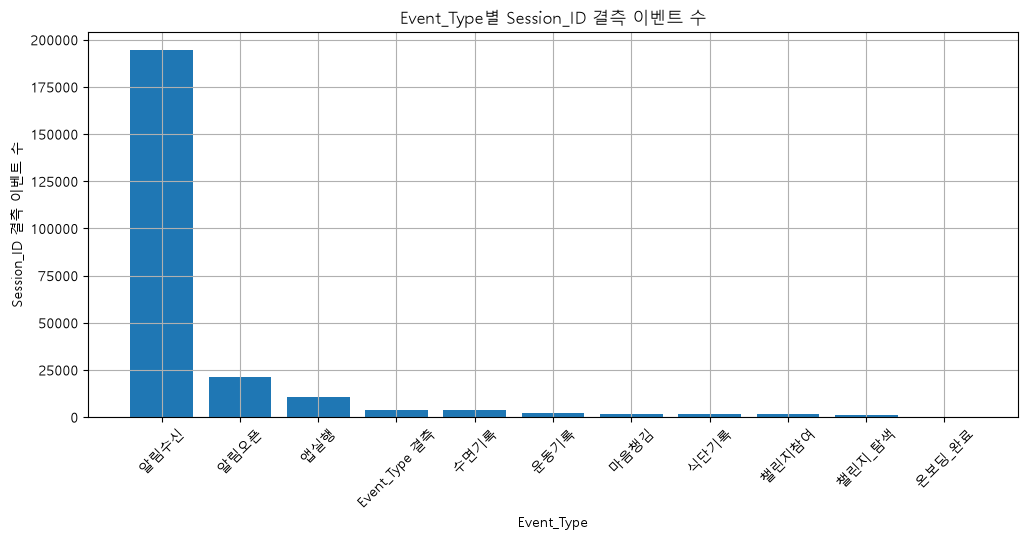

In [135]:
# ============================================================
# 5. Session_ID 결측 구조 확인
# ============================================================

session_check = event_log_eda.copy()

# Session_ID 결측 여부 컬럼 생성
session_check["is_session_missing"] = session_check["Session_ID"].isnull()

session_missing_summary = (
    session_check
    .groupby(["Event_Type", "is_session_missing"], dropna=False)
    .size()
    .reset_index(name="event_count")
)

display(session_missing_summary)


# ============================================================
# 알림 이벤트 여부별 Session_ID 결측률 확인
# ============================================================

session_missing_by_event_group = (
    session_check
    .groupby("is_notification_event")
    .agg(
        event_count=("User_ID", "size"),
        session_missing_count=("is_session_missing", "sum")
    )
    .reset_index()
)

session_missing_by_event_group["session_missing_rate(%)"] = (
    session_missing_by_event_group["session_missing_count"] /
    session_missing_by_event_group["event_count"] * 100
).round(2)

display(session_missing_by_event_group)


# ============================================================
# Event_Type별 Session_ID 결측 이벤트 수 그래프
# ============================================================

session_missing_by_event_type = (
    session_check
    .groupby("Event_Type", dropna=False)
    .agg(
        event_count=("User_ID", "size"),
        session_missing_count=("is_session_missing", "sum")
    )
    .reset_index()
)

session_missing_by_event_type["Event_Type"] = (
    session_missing_by_event_type["Event_Type"]
    .fillna("Event_Type 결측")
    .astype(str)
)

session_missing_by_event_type = session_missing_by_event_type.sort_values(
    by="session_missing_count",
    ascending=False
)

display(session_missing_by_event_type)

plt.figure(figsize=(12, 5))
plt.bar(
    session_missing_by_event_type["Event_Type"],
    session_missing_by_event_type["session_missing_count"]
)

plt.title("Event_Type별 Session_ID 결측 이벤트 수")
plt.xlabel("Event_Type")
plt.ylabel("Session_ID 결측 이벤트 수")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### 결과 해석

`Session_ID` 결측은 알림 이벤트에서 매우 뚜렷하게 나타난다. `알림수신` **194,324건**과 `알림오픈` **21,219건**은 모두 `Session_ID`가 결측이다. 

알림 이벤트는 앱 내부 세션이 아니라 앱 외부 알림에서 발생할 수 있으므로, 이 결측은 데이터 오류라기보다 이벤트 특성으로 보는 것이 적절하다.

반면 알림 이벤트가 아닌 로그에서도 `Session_ID` 결측이 **25,959건**, 비율로는 **1.68%** 존재한다. 이 값은 전체 비중은 크지 않지만, 세션 단위 분석에서는 영향을 줄 수 있다.

따라서 전처리 기준은
- 알림 이벤트의 `Session_ID` 결측은 정상으로 보고 유지
- 세션 길이, 세션별 이벤트 수처럼 `Session_ID`가 필요한 분석에서는 `Session_ID`가 있는 로그만 사용

## 6. 알림_유형 결측 구조 확인

`알림_유형`이 알림 이벤트에만 존재하는 구조인지 확인한다.

,Event_Type,알림_유형,event_count
0,마음챙김,NaN,130344
1,수면기록,NaN,242978
2,식단기록,NaN,101366
3,알림수신,광고성,74958
4,알림수신,리마인드,73667
5,알림수신,챌린지_알림,45699
6,알림오픈,광고성,2101
7,알림오픈,리마인드,10888
8,알림오픈,챌린지_알림,8230
9,앱실행,NaN,728657


,is_notification_event,has_notification_type,event_count
0,False,False,1538380
1,False,True,3339
2,True,True,215543


,알림_유형,event_count,비율(%)
0,리마인드,84555,39.23
1,광고성,77059,35.75
2,챌린지_알림,53929,25.02


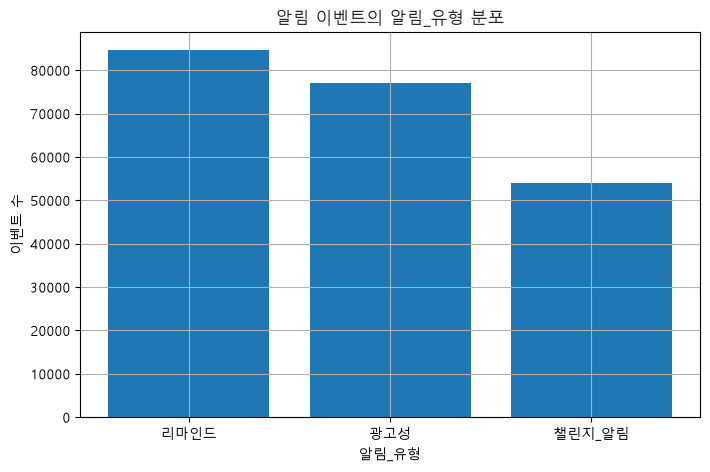

In [137]:
# ============================================================
# 6. 알림_유형 결측 구조 확인
# ============================================================

notification_check = event_log_eda.copy()

notification_type_summary = (
    notification_check
    .groupby(["Event_Type", "알림_유형"], dropna=False)
    .size()
    .reset_index(name="event_count")
)

display(notification_type_summary)


# ============================================================
# 알림_유형 값 존재 여부 확인
# ============================================================

notification_check["has_notification_type"] = notification_check["알림_유형"].notnull()

notification_type_check = (
    notification_check
    .groupby(["is_notification_event", "has_notification_type"])
    .size()
    .reset_index(name="event_count")
)

display(notification_type_check)


# ============================================================
# 알림 이벤트의 알림_유형 분포 그래프
# ============================================================

notification_event_data = notification_check[
    notification_check["is_notification_event"]
].copy()

notification_type_count = (
    notification_event_data["알림_유형"]
    .fillna("알림_유형 결측")
    .value_counts(dropna=False)
    .reset_index()
)

notification_type_count.columns = ["알림_유형", "event_count"]
notification_type_count["비율(%)"] = (
    notification_type_count["event_count"] /
    len(notification_event_data) * 100
).round(2)

display(notification_type_count)

plt.figure(figsize=(8, 5))
plt.bar(
    notification_type_count["알림_유형"],
    notification_type_count["event_count"]
)

plt.title("알림 이벤트의 알림_유형 분포")
plt.xlabel("알림_유형")
plt.ylabel("이벤트 수")
plt.grid(True)
plt.show()


### 결과 해석

`알림_유형`은 대부분 알림 이벤트에서만 존재한다. `알림수신`과 `알림오픈`은 모두 `광고성`, `리마인드`, `챌린지_알림` 중 하나의 알림 유형을 가진다. 반대로 마음챙김, 수면기록, 식단기록, 앱실행 같은 일반 앱 내부 이벤트는 `알림_유형`이 결측이다.

다만 알림 이벤트가 아닌 것으로 분류된 로그 중에서도 `알림_유형`이 존재하는 경우가 **3,339건** 있다. 확인 결과 이들은 `Event_Type`이 결측이지만 `알림_유형`은 존재하는 로그이다.

## 7. 리텐션용 활성 이벤트 기준 후보 확인

리텐션 계산에서 어떤 이벤트를 “활성”으로 볼지 정하기 위해, 알림 이벤트와 앱 내부 이벤트를 분리해 확인한다.

,is_notification_event,is_in_app_event,event_count,user_count
0,False,False,26456,7206
1,False,True,1515263,12453
2,True,False,215543,8139


,event_group,event_count,user_count,이벤트 비율(%)
0,Event_Type 결측,26456,7206,1.51
1,알림 이벤트,215543,8139,12.27
2,앱 내부 이벤트,1515263,12453,86.23


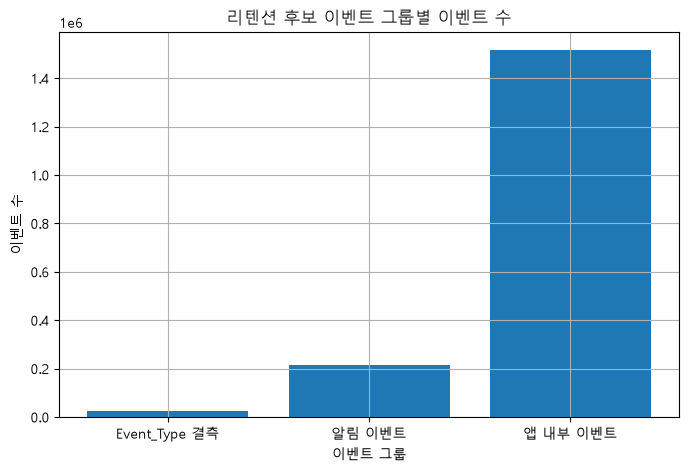

전체 이벤트 수: 1757262
앱 내부 이벤트 수: 1515263
앱 내부 이벤트 사용자 수: 12453


In [138]:
# ============================================================
# 7. 리텐션용 활성 이벤트 기준 후보 확인
# ============================================================

active_event_summary = (
    event_log_eda
    .groupby(["is_notification_event", "is_in_app_event"], dropna=False)
    .agg(
        event_count=("User_ID", "size"),
        user_count=("User_ID", "nunique")
    )
    .reset_index()
)

display(active_event_summary)


# ============================================================
# 이벤트 그룹 생성
# ============================================================

active_group_data = event_log_eda.copy()

conditions = [
    active_group_data["is_in_app_event"],
    active_group_data["is_notification_event"],
    active_group_data["Event_Type"].isnull()
]

choices = [
    "앱 내부 이벤트",
    "알림 이벤트",
    "Event_Type 결측"
]

active_group_data["event_group"] = np.select(
    conditions,
    choices,
    default="기타"
)

active_group_summary = (
    active_group_data
    .groupby("event_group")
    .agg(
        event_count=("User_ID", "size"),
        user_count=("User_ID", "nunique")
    )
    .reset_index()
)

active_group_summary["이벤트 비율(%)"] = (
    active_group_summary["event_count"] /
    len(active_group_data) * 100
).round(2)

display(active_group_summary)


# ============================================================
# 리텐션 후보 이벤트 그룹 그래프
# ============================================================

plt.figure(figsize=(8, 5))
plt.bar(active_group_summary["event_group"], active_group_summary["event_count"])
plt.title("리텐션 후보 이벤트 그룹별 이벤트 수")
plt.xlabel("이벤트 그룹")
plt.ylabel("이벤트 수")
plt.grid(True)
plt.show()


# 리텐션 계산 후보 데이터
active_log = event_log_eda[event_log_eda["is_in_app_event"]].copy()

print("전체 이벤트 수:", len(event_log_eda))
print("앱 내부 이벤트 수:", len(active_log))
print("앱 내부 이벤트 사용자 수:", active_log["User_ID"].nunique())


### 결과 해석

리텐션 계산 후보로 볼 수 있는 앱 내부 이벤트는 **1,515,263건**이고, 해당 이벤트를 남긴 사용자는 **12,453명**이다. 알림 이벤트는 **215,543건**, 사용자 수는 **8,139명**으로 확인된다. 

`Event_Type` 결측으로 인해 앱 내부 이벤트도 알림 이벤트도 아닌 로그는 **26,456건**이다.

리텐션은 사용자가 실제로 서비스를 다시 사용했는지를 보는 지표이기 때문에, 알림 수신 자체를 활성 행동으로 포함하면 리텐션이 과대평가될 수 있다.  
알림 오픈도 앱 사용으로 이어졌는지 명확하지 않기 때문에, 기본 리텐션 계산에서는 제외하는 편이 안전하다.

따라서 리텐션용 활성 기준은 `알림수신`, `알림오픈`, `Event_Type` 결측을 제외한 앱 내부 행동 이벤트로 잡는 것이 적절할것으로 확인된다.   
이때 알림 이벤트는 리텐션 계산이 아니라 알림 반응률 분석에서 따로 활용하는 것이 좋을것으로 예상된다.

## 8. D7 / D30 관측 가능 사용자 확인

가입일 기준으로 D7, D30 리텐션을 계산할 수 있는 사용자가 얼마나 되는지 확인한다.

,항목,사용자 수,비율(%)
0,전체 가입자 수,12500,100.0
1,D7 관측 가능 사용자 수,12500,100.0
2,D30 관측 가능 사용자 수,12500,100.0
3,D7 관측 불가능 사용자 수,0,0.0
4,D30 관측 불가능 사용자 수,0,0.0


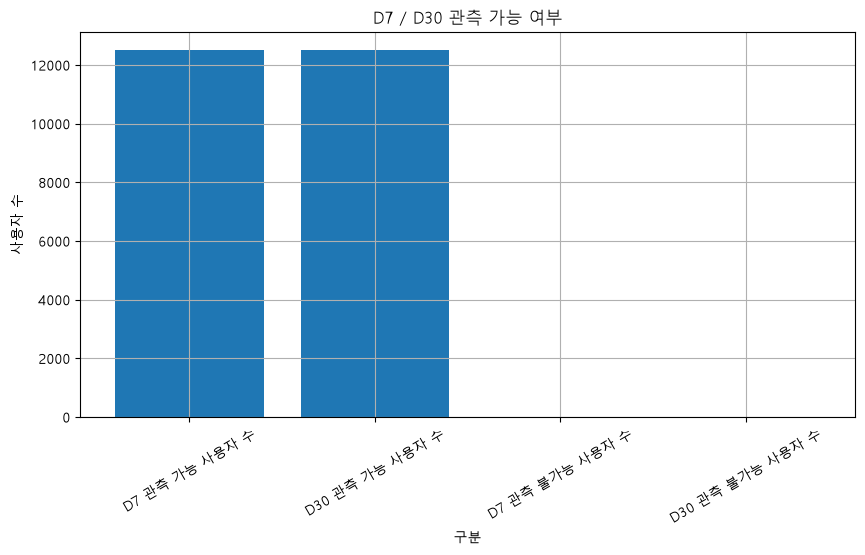

In [139]:
# ============================================================
# 8. D7 / D30 관측 가능 사용자 확인
# ============================================================

user_profile_eda["can_observe_d7"] = (
    user_profile_eda["가입일자"] + pd.Timedelta(days=7) <= data_end_date
)

user_profile_eda["can_observe_d30"] = (
    user_profile_eda["가입일자"] + pd.Timedelta(days=30) <= data_end_date
)

observe_summary = pd.DataFrame({
    "항목": [
        "전체 가입자 수",
        "D7 관측 가능 사용자 수",
        "D30 관측 가능 사용자 수",
        "D7 관측 불가능 사용자 수",
        "D30 관측 불가능 사용자 수"
    ],
    "사용자 수": [
        user_profile_eda["User_ID"].nunique(),
        user_profile_eda["can_observe_d7"].sum(),
        user_profile_eda["can_observe_d30"].sum(),
        (~user_profile_eda["can_observe_d7"]).sum(),
        (~user_profile_eda["can_observe_d30"]).sum()
    ]
})

observe_summary["비율(%)"] = (
    observe_summary["사용자 수"] / user_profile_eda["User_ID"].nunique() * 100
).round(2)

display(observe_summary)


# ============================================================
# D7 / D30 관측 가능 사용자 수 그래프
# ============================================================

observe_plot_df = observe_summary[
    observe_summary["항목"].isin([
        "D7 관측 가능 사용자 수",
        "D30 관측 가능 사용자 수",
        "D7 관측 불가능 사용자 수",
        "D30 관측 불가능 사용자 수"
    ])
].copy()

plt.figure(figsize=(10, 5))
plt.bar(observe_plot_df["항목"], observe_plot_df["사용자 수"])
plt.title("D7 / D30 관측 가능 여부")
plt.xlabel("구분")
plt.ylabel("사용자 수")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()



### 결과 해석

가입일 기준으로 D7과 D30을 관측할 수 있는 사용자는 모두 **12,500명, 100%**로 확인되었다. 가입일자의 최댓값이 **2025-05-26**이고, 이벤트 로그가 **2025-06-30**까지 존재하기 때문에 모든 가입자에 대해 가입 후 30일까지의 관측 기간이 확보된다.

따라서 D7, D30 리텐션 분석에서 관측 기간 부족으로 제외해야 하는 사용자는 없는것으로 판단된다. 


다만 3월 10~14일 로그 수집 장애 기간이 특정 사용자의 D7 또는 D30 구간에 포함될 수 있으므로, 해당 영향은 별도 플래그를 남기는 등의 해석상 주의해야 한다.

## 9. 사용자별 활동량 분포 확인

고활동 사용자가 존재하는지, 활동량 차이가 큰지 확인한다. 이 결과는 이상치 제거 여부가 아니라 **사용자 세그먼트 분리 기준**을 정하는 데 활용한다.

,User_ID,event_count,active_event_count,notification_event_count,session_count,active_day_count,challenge_event_count
0,U0000001,515,425,87,202,80,64
1,U0000002,55,53,0,21,10,18
2,U0000003,3,3,0,2,1,0
3,U0000004,89,68,21,38,20,4
4,U0000005,442,353,85,187,82,25


,count,mean,std,min,25%,50%,75%,max
event_count,12453.0,141.111539,172.167588,1.0,20.0,51.0,219.0,697.0
active_event_count,12453.0,121.678551,149.527723,1.0,17.0,44.0,178.0,624.0
notification_event_count,12453.0,17.308520,28.038124,0.0,0.0,3.0,15.0,102.0
session_count,12453.0,59.124789,72.020809,0.0,8.0,21.0,92.0,262.0
active_day_count,12453.0,24.852967,28.607670,1.0,3.0,9.0,54.0,89.0
challenge_event_count,12453.0,14.047218,20.583966,0.0,1.0,4.0,17.0,100.0


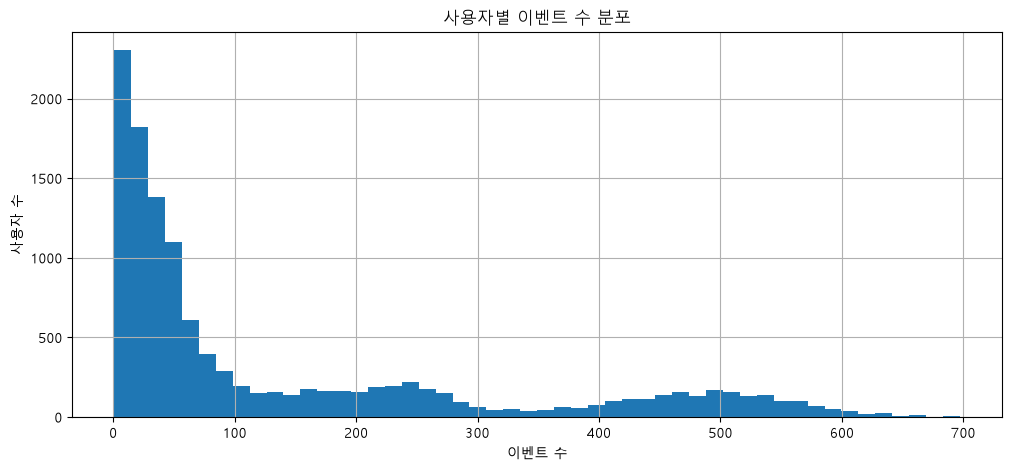

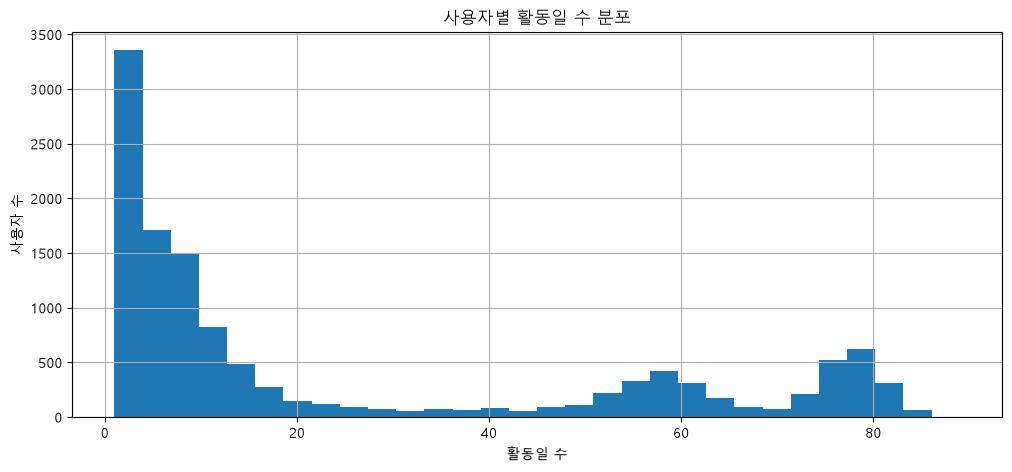

In [140]:
# ============================================================
# 9. 사용자별 활동량 집계
# ============================================================

# 사용자별 활동량 집계
user_activity_summary = (
    event_log_eda
    .groupby("User_ID")
    .agg(
        event_count=("User_ID", "size"),                         # 사용자별 전체 이벤트 수
        active_event_count=("is_in_app_event", "sum"),            # 사용자별 앱 내부 이벤트 수
        notification_event_count=("is_notification_event", "sum"), # 사용자별 알림 이벤트 수
        session_count=("Session_ID", "nunique"),                  # 사용자별 세션 수
        active_day_count=("Event_Date", "nunique"),               # 사용자별 활동일 수
        challenge_event_count=("is_challenge_event", "sum")        # 사용자별 챌린지 관련 이벤트 수
    )
    .reset_index()
)

# 사용자별 집계 결과 일부 확인
display(user_activity_summary.head())

# 수치형 컬럼의 기본 통계량 확인
display(user_activity_summary.describe().T)


# ============================================================
# 사용자별 이벤트 수 분포 그래프
plt.figure(figsize=(12, 5))
plt.hist(user_activity_summary["event_count"], bins=50)
plt.title("사용자별 이벤트 수 분포")
plt.xlabel("이벤트 수")
plt.ylabel("사용자 수")
plt.grid(True)
plt.show()


# ============================================================
# 사용자별 활동일 수 분포 그래프
plt.figure(figsize=(12, 5))
plt.hist(user_activity_summary["active_day_count"], bins=30)
plt.title("사용자별 활동일 수 분포")
plt.xlabel("활동일 수")
plt.ylabel("사용자 수")
plt.grid(True)
plt.show()

### 결과 해석

사용자별 전체 이벤트 수는 평균 **141.1건**이지만 중앙값은 **51건**이다.     
평균이 중앙값보다 훨씬 크다는 것은 일부 사용자가 매우 많은 이벤트를 남기고 있다는 뜻이다.   
최댓값은 **697건**으로, 사용자 간 활동량 차이가 큰 편이다.

앱 내부 이벤트도 평균 **121.7건**, 중앙값 **44건**으로 비슷한 형태를 보인다.    
활동일 수는 평균 **24.9일**, 중앙값 **9일**이고, 세션 수는 평균 **59.1개**, 중앙값 **21개**이다.         
즉, 대부분의 사용자는 짧고 적게 활동하지만, 일부 사용자는 장기간 높은 빈도로 활동한다.

이때 이벤트 수가 많은 사용자는 오류 데이터가 아니라 핵심 고활동 사용자일 수 있다.       
이후 분석에서는 활동량에 따라 저활동/중간/고활동 사용자 세그먼트를 나누고, 각 세그먼트의 리텐션 차이를 비교하는 방식이 적절할것으로 보인다.

## 10. 온보딩 / 챌린지 경험 여부 확인

이후 가설 검증에서 사용할 온보딩 완료, 챌린지 탐색, 챌린지 참여 경험 여부를 사용자 단위로 확인한다.

,항목,사용자 수,비율(%)
0,has_onboarding,5719,45.75
1,has_challenge_explore,9104,72.83
2,has_challenge_join,9372,74.98
3,has_notification_open,5127,41.02


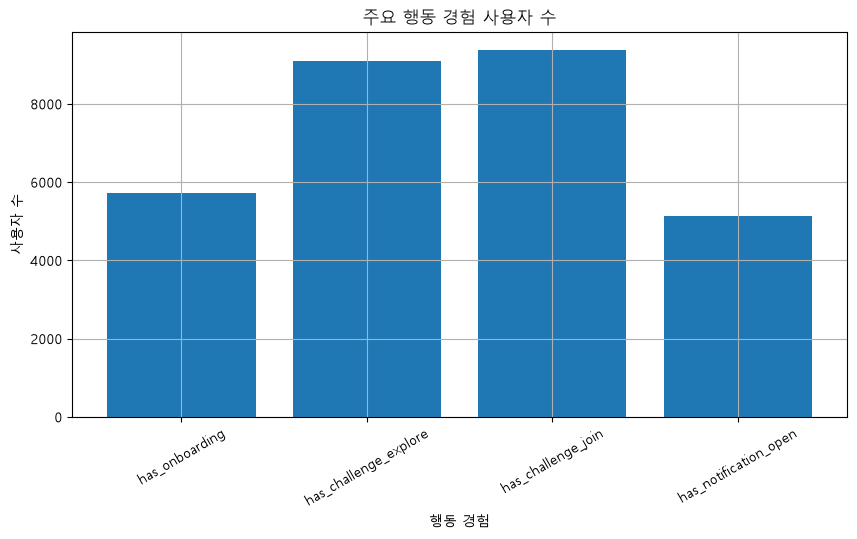

In [141]:
# ============================================================
# 10. 온보딩 / 챌린지 경험 여부 확인
# ============================================================

event_flag_data = event_log_eda.copy()

# 이벤트별 경험 여부 컬럼 생성
# 해당 이벤트면 True, 아니면 False
event_flag_data["has_onboarding"] = event_flag_data["Event_Type"] == "온보딩_완료"
event_flag_data["has_challenge_explore"] = event_flag_data["Event_Type"] == "챌린지_탐색"
event_flag_data["has_challenge_join"] = event_flag_data["Event_Type"] == "챌린지참여"
event_flag_data["has_notification_open"] = event_flag_data["Event_Type"] == "알림오픈"

# 사용자별로 한 번이라도 해당 이벤트를 했는지 확인
user_event_flags = (
    event_flag_data
    .groupby("User_ID")
    .agg(
        has_onboarding=("has_onboarding", "max"),
        has_challenge_explore=("has_challenge_explore", "max"),
        has_challenge_join=("has_challenge_join", "max"),
        has_notification_open=("has_notification_open", "max")
    )
    .reset_index()
)

# User_Profile 기준으로 left join
user_profile_with_flags = user_profile_eda.merge(
    user_event_flags,
    on="User_ID",
    how="left"
)

# 이벤트 로그가 없는 사용자는 해당 행동을 한 기록이 없으므로 False로 처리
flag_cols = [
    "has_onboarding",
    "has_challenge_explore",
    "has_challenge_join",
    "has_notification_open"
]

for col in flag_cols:
    user_profile_with_flags[col] = user_profile_with_flags[col].fillna(False)
    user_profile_with_flags[col] = user_profile_with_flags[col].astype(bool)

# 경험 여부별 사용자 수와 비율 정리
flag_summary = pd.DataFrame({
    "항목": flag_cols,
    "사용자 수": [
        user_profile_with_flags[col].sum()
        for col in flag_cols
    ],
    "비율(%)": [
        round(user_profile_with_flags[col].mean() * 100, 2)
        for col in flag_cols
    ]
})

display(flag_summary)


# 주요 행동 경험 사용자 수 그래프
plt.figure(figsize=(10, 5))
plt.bar(flag_summary["항목"], flag_summary["사용자 수"])
plt.title("주요 행동 경험 사용자 수")
plt.xlabel("행동 경험")
plt.ylabel("사용자 수")
plt.xticks(rotation=30)
plt.grid(True)
plt.show()


### 결과 해석

온보딩 완료 경험자는 **5,719명, 45.75%**로 절반보다 낮으나 반면 챌린지 탐색 경험자는 **9,104명, 72.83%**, 챌린지 참여 경험자는 **9,372명, 74.98%**로 높게 나타났다.         
알림 오픈 경험자는 **5,127명, 41.02%**이다.

특이하게도 챌린지 참여 비율이 챌린지 탐색 비율보다 약간 높다.   
일반적인 경우엔 탐색 후 참여가 자연스러우나,    
데이터 구조상 참여 이벤트가 탐색 없이도 발생할 수 있거나, 탐색 로그가 일부 누락되었을 가능성이 있다.

때문에 가설 검증에서는 `챌린지_탐색`과 `챌린지참여`를 하나로 합치기보다 분리해서 보는 것이 좋을것으로 판별된다. 
경험은 `챌린지참여`로 보고, `챌린지_탐색`은 관심 행동 또는 사전 행동으로 따로 해석하는 방식이 적절할것이다.

## 11. 이벤트 로그가 없는 가입자 확인

프로필에는 존재하지만 이벤트 로그에는 없는 사용자를 확인한다. 이 사용자를 리텐션 분모에 포함할지 여부는 이후 분석 기준에 영향을 준다.

In [142]:
# ============================================================
# 11. 이벤트 로그가 없는 가입자 확인
# ============================================================

# User_Profile, Event_Log에 존재하는 사용자 집합
profile_user_set = set(user_profile_eda["User_ID"])
event_user_set = set(event_log_eda["User_ID"])

# 프로필에는 있지만 이벤트 로그에는 없는 사용자
only_profile_users = profile_user_set - event_user_set

print("프로필에만 존재하는 사용자 수:", len(only_profile_users))

# 해당 사용자들의 프로필 정보 확인
only_profile_df = user_profile_eda[
    user_profile_eda["User_ID"].isin(only_profile_users)
].copy()

display(only_profile_df.head())

# 이벤트 로그가 없는 사용자의 가입월 분포 확인
if len(only_profile_df) > 0:
    only_profile_monthly = (
        only_profile_df
        .groupby("가입월")
        .size()
        .reset_index(name="user_count")
    )

    display(only_profile_monthly)


프로필에만 존재하는 사용자 수: 47


,User_ID,가입일자,가입경로,기기,알림수신동의여부,알림수신동의_변경일자,가입일,가입월,can_observe_d7,can_observe_d30
112,U0000113,2025-03-10,퍼포먼스광고,NaN,True,NaT,2025-03-10,2025-03,True,True
536,U0000537,2025-03-12,퍼포먼스광고,iOS,True,NaT,2025-03-12,2025-03,True,True
559,U0000560,2025-03-14,퍼포먼스광고,Android,True,NaT,2025-03-14,2025-03,True,True
871,U0000872,2025-03-10,오가닉,iOS,False,NaT,2025-03-10,2025-03,True,True
1645,U0001646,2025-03-10,오가닉,iOS,True,NaT,2025-03-10,2025-03,True,True


,가입월,user_count
0,2025-03,47


### 결과 해석
프로필에는 존재하지만 이벤트 로그에는 없는 사용자는 **47명**이다.   
전체 가입자 **12,500명** 중 매우 작은 비중이나, 이 사용자를 어떻게 처리하느냐에 따라 데이터의 질이 결정된다.

특히, 이 47명은 모두 **2025년 3월 가입자**로 확인된다. 샘플에서도 3월 10일, 3월 12일, 3월 14일 가입자가 보이는데, 이는 로그 수집 장애 기간과 겹친다.    
따라서 이들을 단순히 가입 후 아무 활동도 하지 않은 사용자라고만 보기에는 조심스럽다.

전처리 중 이 사용자를 삭제하기보다 `no_event_log` 같은 플래그로 표시하는 것이 좋을것 같다.


In [143]:
# 프로필에만 존재하는 사용자의 가입일별 사용자 수 확인
only_profile_day_count = (
    only_profile_df["가입일"]
    .value_counts()
    .sort_index()
    .reset_index()
)

only_profile_day_count.columns = ["가입일", "사용자 수"]

display(only_profile_day_count)

,가입일,사용자 수
0,2025-03-10,13
1,2025-03-11,12
2,2025-03-12,13
3,2025-03-13,7
4,2025-03-14,2


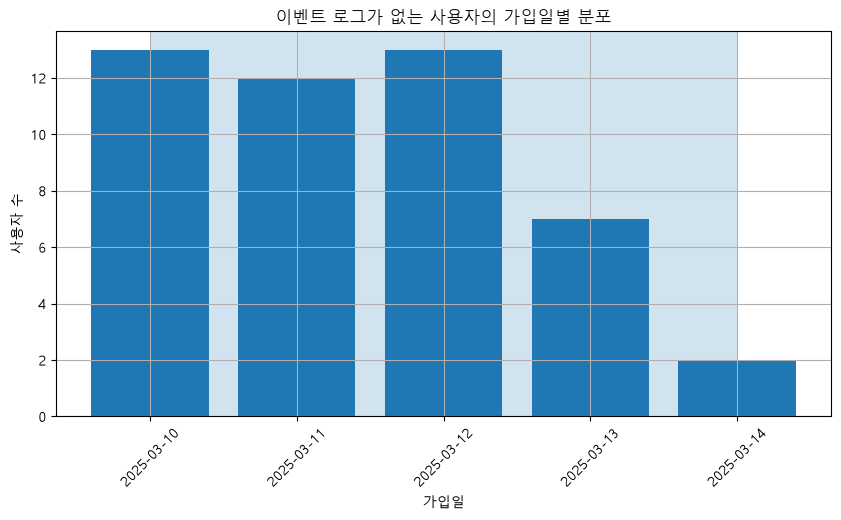

In [144]:
plt.figure(figsize=(10, 5))
plt.bar(
    only_profile_day_count["가입일"],
    only_profile_day_count["사용자 수"]
)

plt.axvspan(issue_start_date, issue_end_date, alpha=0.2)

plt.title("이벤트 로그가 없는 사용자의 가입일별 분포")
plt.xlabel("가입일")
plt.ylabel("사용자 수")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


### 추가 해석 해석


해당 기간은 과제에서 안내된 **로그 수집 장애 기간과 정확히 겹친다.**      
따라서 이 47명은 실제로 가입 후 아무 활동도 하지 않은 사용자라기보다, **가입 이후 행동 로그가 정상적으로 수집되지 않았을 가능성**이 있다.

즉, 이 사용자를 일반적인 미활동 사용자로 처리하면 리텐션이나 초기 행동 분석 결과가 왜곡될 수 있다.  
특히 D1, D7 리텐션 계산에서 이들을 단순 이탈자로 포함하면 해당 기간 가입자의 리텐션이 실제보다 낮게 계산될 수 있다.

따라서 전처리 단계에서는 이 사용자를 삭제하기보다, `no_event_log` 또는 `issue_period_signup` 같은 플래그를 생성해 별도로 구분하는 것이 적절하다.    
이후 리텐션 분석에서는 전체 기준 결과와 함께, 해당 사용자를 제외한 민감도 분석도 함께 비교할 필요가 있다.

# EDA 후 전처리 기준 메모

위 탐색 결과를 바탕으로 다음 기준을 확정한다.

1. **리텐션 계산에서 사용할 활성 이벤트 기준**  
   - 알림 이벤트를 제외하고 앱 내부 행동 이벤트만 사용할지 결정

2. **`Event_Type` 결측 처리 기준**  
   - 행동 분석에서 제외할지, `Unknown`으로 유지할지 결정

3. **`Session_ID` 결측 처리 기준**  
   - 알림 이벤트의 결측은 정상으로 보고, 세션 분석에서는 `Session_ID`가 있는 로그만 사용할지 결정

4. **`알림_유형` 결측 처리 기준**  
   - 알림 이벤트가 아닌 경우의 결측은 정상으로 볼지 결정

5. **D7/D30 관측 가능 사용자 기준**  
   - 가입일 기준 관측 가능 사용자만 리텐션 분모에 포함할지 결정

6. **로그 수집 장애 기간 처리 기준**  
   - 제거하지 않고 플래그 처리할지, 민감도 분석에서 제외 비교할지 결정

7. **고활동 사용자 처리 기준**  
   - 이상치로 제거하지 않고 별도 사용자 세그먼트로 볼지 결정

8. **프로필에만 있고 이벤트 로그가 없는 사용자 처리 기준**  
   - 가입 후 미활동 사용자로 보고 리텐션 분모에 포함할지 결정

9. **챌린지 경험자 정의**  
   - `챌린지_탐색`과 `챌린지참여`를 분리해서 볼지, `챌린지참여`를 핵심 경험으로 볼지 결정